In [3]:
from xgboost import XGBClassifier, XGBRegressor
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.metrics import accuracy_score, roc_auc_score, r2_score, mean_squared_error, root_mean_squared_error, root_mean_squared_log_error, mean_absolute_error, f1_score, recall_score, precision_score, confusion_matrix, matthews_corrcoef
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split

In [4]:
from digit_fr.core.paths import root_path
df = pd.read_csv(root_path('data', 'raw', 'fed_recommenders_synthetic_dataset.csv'))
target_class = "Removal_Indicated"
target_risks = ["Risk_AlveolarOsteitis", "Risk_SecondaryInfection", "Risk_NerveDysesthesia", "Risk_Bleeding"]
leakage_cols = ["Patient", "Client", "Removal_Prob", "Score_1", "Score_2", "Score_3", "Prob_1", "Prob_2", "Prob_3"]

In [5]:
X = df.drop(columns=[target_class] + leakage_cols + target_risks)
y_class = df[target_class]
y_risks = df[target_risks]


In [6]:
X_train, X_test, y_class_train, y_class_test, y_risks_train, y_risks_test = train_test_split(X, y_class, y_risks, test_size=0.2, random_state=42)


## Removal indicated classification


In [7]:
xgb_clf = XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, random_state=42)
xgb_clf.fit(X_train, y_class_train)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=None, num_parallel_tree=None, ...)

In [8]:
y_class_predict = xgb_clf.predict(X_test)
y_class_prob = xgb_clf.predict_proba(X_test)[:, 1]


In [9]:
print(f"Accuracy: {accuracy_score(y_class_test, y_class_predict)}")
print(f"ROC AUC:  {roc_auc_score(y_class_test, y_class_prob)}")
print(f"F1 Score: {f1_score(y_class_test, y_class_predict)}")
print(f"Recall Score: {recall_score(y_class_test, y_class_predict)}")
print(f"Precision Score: {precision_score(y_class_test, y_class_predict)}")
print("MCC:", matthews_corrcoef(y_class_test, y_class_predict))

Accuracy: 0.925
ROC AUC:  0.9046379775072033
F1 Score: 0.96
Recall Score: 0.9703504043126685
Precision Score: 0.9498680738786279
MCC: 0.36644819231981446


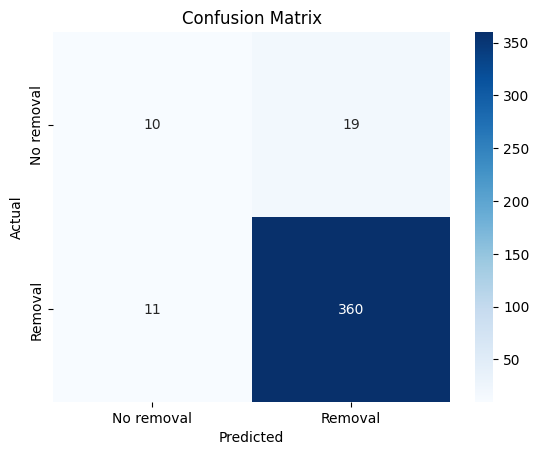

In [10]:
cm = confusion_matrix(y_class_test, y_class_predict)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No removal', 'Removal'],
            yticklabels=['No removal', 'Removal'])
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

### highly imbalanced dataset (~92% removal indicated) shows in the performance of the minority class

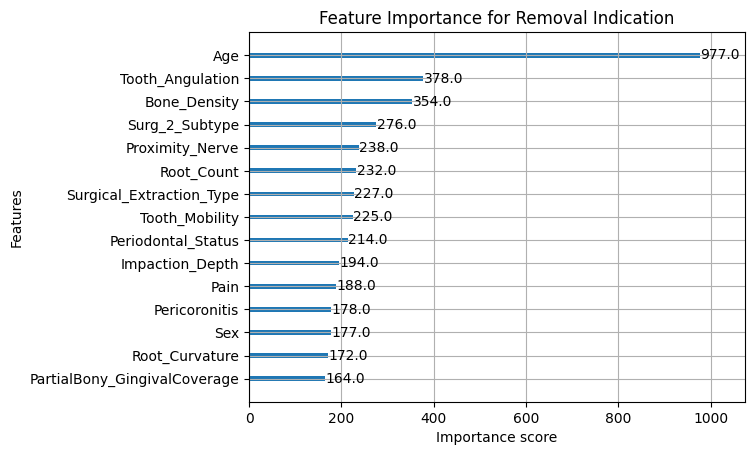

In [11]:
xgb.plot_importance(xgb_clf, max_num_features=15)
plt.title("Feature Importance for Removal Indication")
plt.show()


## Risk prediction
* the two step approach for the Nerve_Dysesthesia risk does not work well (first classifying if 0 or non-zero and then training a regression model on the non-zero values) because later on the model has to predict the 0.0 values without ever seeing them. It has to predict in a feature space it did not learn
* -> only predict a risk for mandibular, only train on mandibular


In [12]:
results = []
risk_preds = pd.DataFrame(index=X_test.index)

for risk in target_risks:
    xgb_reg = XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, random_state=42)
    xgb_reg.fit(X_train, y_risks_train[risk])
    y_risks_pred = xgb_reg.predict(X_test)

    risk_preds[risk + "_pred"] = y_risks_pred

    r2 = r2_score(y_risks_test[risk], y_risks_pred)
    rmse = root_mean_squared_error(y_risks_test[risk], y_risks_pred)
    mse = mean_squared_error(y_risks_test[risk], y_risks_pred)
    mae = mean_absolute_error(y_risks_test[risk], y_risks_pred)
    rmsle = root_mean_squared_log_error(y_risks_test[risk], y_risks_pred)
    results.append((risk, r2, rmse, mse, mae, rmsle))

risk_performance = pd.DataFrame(results, columns=["Risks", "R2", "RMSE", "MSE", "MAE", "RMSLE"])
risk_performance


,Risks,R2,RMSE,MSE,MAE,RMSLE
0,Risk_AlveolarOsteitis,0.999030,0.000415,1.724408e-07,0.000298,0.000391
1,Risk_SecondaryInfection,0.998104,0.000603,3.632043e-07,0.000316,0.000573
2,Risk_NerveDysesthesia,0.984849,0.000714,5.098838e-07,0.000350,0.000703
3,Risk_Bleeding,0.990288,0.000075,5.692445e-09,0.000044,0.000075


## Check some predicted risks against actual values


In [13]:
comparison = y_risks_test.copy()
for risk in target_risks:
    comparison[risk + "_pred"] = risk_preds[risk + "_pred"]


In [ ]:
print("Sample patients - Actual vs Predicted Risk Values")
sample_indices = comparison.sample(n=5, random_state=42).index
for idx in sample_indices:
    print(f"\nPatient Index: {idx}")
    print(comparison.loc[[idx]].T)